# 04 — Feature Engineering

**Project:** Healthcare Readmission Intelligence  
**Input:** `data/processed/train.csv` and `data/processed/test.csv`  
**Output:** `data/features/train_features.csv` and `data/features/test_features.csv`

## Objective

Transform the cleaned dataset into a model-ready feature set.  
Every decision here is directly motivated by findings from `03_exploratory_data_analysis.ipynb`.

## Feature Engineering Plan

| Step | What | Why (from EDA) |
| ---- | ---- | -------------- |
| 1 | Drop near-zero-variance medications | >99% "No" — add noise, no signal |
| 2 | Create `total_prior_visits` | Inpatient + emergency + outpatient all correlated with readmission |
| 3 | Create `high_utilizer` flag | EDA showed a small group with very high visit counts — binary flag captures this |
| 4 | Encode `age` as ordinal integer | Readmission rate increases with age (generally) |
| 5 | Encode `insulin` as ordinal integer | Up/Down showed higher readmission than No/Steady |
| 6 | Collapse remaining medications to Yes/No | Key question is prescribed or not — simplifies Pipeline encoding later |
| 7 | Impute missing values | `payer_code` → "Unknown", `race` → mode (train only) |
| 8 | Final checks and save | Sanity check before modelling |

> **Design decision:** Categorical encoding (one-hot for `race`, `payer_code`, `diag_group`, etc.)
> and binary encoding for `change`, `diabetesMed`, `gender` will be handled **inside the sklearn
> Pipeline** in `05_baseline_models.ipynb`. This notebook only does the transformations that
> require domain knowledge or data-driven decisions (ordinal mappings, feature creation).
>
> **Leakage rule:** All transformations that learn from data (mode imputation, quantile threshold)
> are **fit on train only**, then applied to test.

## Setup

In [1]:
import warnings
import os
import sys
import yaml

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
sys.path.append(os.path.abspath('..'))
from configs.features import (
    NUMERICAL_FEATURES,
    CLINICAL_FEATURES,
    MEDICATION_FEATURES,
    DEMOGRAPHIC_FEATURES
)

## Load Data

In [3]:
CONFIG_PATH = '../configs/paths.yaml'

with open(CONFIG_PATH,"r") as file:
    paths = yaml.safe_load(file)

train = pd.read_csv(paths['processed_data']['train_data'])
test  = pd.read_csv(paths['processed_data']['test_data'])

print(f"Train shape: {train.shape}")
print(f"Test shape : {test.shape}")
train.head()

Train shape: (81477, 45)
Test shape : (20289, 45)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary,diag_1_group,diag_2_group,diag_3_group,medical_specialty_group
0,Caucasian,Female,[0-10),6,25,1,1,NaN,41,0,1,0,0,0,1,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,Diabetes,Unknown,Unknown,Pediatrics
1,Caucasian,Female,[10-20),1,1,7,3,NaN,59,0,18,0,0,0,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,Other,Diabetes,Other,Missing
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,11,5,13,2,0,1,6,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0,Other,Diabetes,Other,Missing
3,Caucasian,Male,[30-40),1,1,7,2,NaN,44,1,16,0,0,0,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,Other,Diabetes,Circulatory,Missing
4,Caucasian,Male,[50-60),2,1,2,3,NaN,31,6,16,0,0,0,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,0,Circulatory,Circulatory,Diabetes,Missing


In [4]:
TARGET = 'readmitted_binary'

y_train = train[TARGET].copy()
y_test  = test[TARGET].copy()

X_train = train.drop(columns=[TARGET]).copy()
X_test  = test.drop(columns=[TARGET]).copy()

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   |  y_test : {y_test.shape}")

X_train: (81477, 44)  |  y_train: (81477,)
X_test : (20289, 44)   |  y_test : (20289,)


## Step 1 — Drop Near-Zero-Variance Medications

**From EDA:** The following medications are prescribed in fewer than 1% of encounters.  
They add no discriminative signal but increase dimensionality and noise.

In [5]:
NZV_MEDICATIONS = [
    'acetohexamide',
    'tolbutamide',
    'troglitazone',
    'examide',
    'citoglipton',
    'miglitol',
    'tolazamide',
    'glimepiride-pioglitazone',
    'metformin-rosiglitazone',
    'metformin-pioglitazone',
]

X_train.drop(columns=NZV_MEDICATIONS, inplace=True)
X_test.drop(columns=NZV_MEDICATIONS, inplace=True)

print(f"Dropped {len(NZV_MEDICATIONS)} near-zero-variance medication columns")
print(f"X_train shape after drop: {X_train.shape}")

Dropped 10 near-zero-variance medication columns
X_train shape after drop: (81477, 34)


## Step 2 — Create `total_prior_visits`

**From EDA:** `number_inpatient`, `number_emergency`, and `number_outpatient` all showed  
higher mean values for readmitted patients. Summing them captures overall healthcare utilization  
in a single feature.

| Feature | Class 0 mean | Class 1 mean |
| ------- | ------------ | ------------ |
| `number_inpatient` | ~0.35 | ~0.85 |
| `number_emergency` | ~0.19 | ~0.38 |
| `number_outpatient`| ~0.85 | ~1.10 |

In [6]:
for df in [X_train, X_test]:
    df['total_prior_visits'] = (
        df['number_inpatient'] +
        df['number_emergency'] +
        df['number_outpatient']
    )

print("Created: total_prior_visits")
print(X_train['total_prior_visits'].describe().round(2))

Created: total_prior_visits
count    81477.00
mean         1.21
std          2.31
min          0.00
25%          0.00
50%          0.00
75%          2.00
max         80.00
Name: total_prior_visits, dtype: float64


In [7]:
print("Mean total_prior_visits by class:")
print(pd.DataFrame({
    'total_prior_visits': X_train['total_prior_visits'],
    'readmitted': y_train
}).groupby('readmitted')['total_prior_visits'].mean().round(3))

Mean total_prior_visits by class:
readmitted
0    1.109
1    2.009
Name: total_prior_visits, dtype: float64


#### Observation

Class 1 patients (readmitted) have nearly **twice** the prior visit count vs class 0 (2.009 vs 1.109).  
This confirms `total_prior_visits` captures meaningful signal.

## Step 3 — Create `high_utilizer` Flag

**From EDA:** The distributions of outpatient/emergency/inpatient visits are heavily right-skewed.  
A small group of patients have very high counts — these "frequent utilizers" are clinically  
distinct and likely have a much higher readmission risk.

**Definition:** `high_utilizer = 1` if `total_prior_visits` is at or above the 85th percentile  
of the training set. Threshold is computed on train only.

In [8]:
# Fit threshold on training set only
threshold = X_train['total_prior_visits'].quantile(0.85)
print(f"85th percentile of total_prior_visits (train): {threshold}")

for df in [X_train, X_test]:
    df['high_utilizer'] = (df['total_prior_visits'] >= threshold).astype(int)

print(f"\nhigh_utilizer distribution (train):")
print(X_train['high_utilizer'].value_counts())

85th percentile of total_prior_visits (train): 3.0

high_utilizer distribution (train):
high_utilizer
0    68654
1    12823
Name: count, dtype: int64


In [9]:
print("Readmission rate by high_utilizer flag:")
print(pd.DataFrame({
    'high_utilizer': X_train['high_utilizer'],
    'readmitted': y_train
}).groupby('high_utilizer')['readmitted'].mean().mul(100).round(2))

Readmission rate by high_utilizer flag:
high_utilizer
0     9.88
1    18.78
Name: readmitted, dtype: float64


#### Observation

High utilizers (top 15% by prior visits) have a **18.78%** readmission rate vs **9.88%** for  
the rest — nearly double. This binary flag will be a strong feature for the Random Forest.

## Step 4 — Encode `age` as Ordinal Integer

**From EDA:** Readmission risk generally increases with age — older patients have more  
comorbidities and recover more slowly after discharge.

The age brackets are already ordered strings — mapping them to 0–9 integers  
preserves this ordering and lets tree-based models split on it as a continuous value.

In [10]:
AGE_ORDINAL = {
    '[0-10)' : 0,
    '[10-20)': 1,
    '[20-30)': 2,
    '[30-40)': 3,
    '[40-50)': 4,
    '[50-60)': 5,
    '[60-70)': 6,
    '[70-80)': 7,
    '[80-90)': 8,
    '[90-100)': 9
}

for df in [X_train, X_test]:
    df['age'] = df['age'].map(AGE_ORDINAL)

print("age encoded as ordinal integer:")
print(X_train['age'].value_counts().sort_index())

age encoded as ordinal integer:
age
0      133
1      570
2     1330
3     3013
4     7782
5    13847
6    17859
7    21006
8    13718
9     2219
Name: count, dtype: int64


In [11]:
print("Mean readmission rate by age group (ordinal):")
print(pd.DataFrame({'age': X_train['age'], 'readmitted': y_train})
      .groupby('age')['readmitted'].mean().mul(100).round(2))

Mean readmission rate by age group (ordinal):
age
0     2.26
1     6.67
2    14.81
3    11.55
4    10.31
5     9.88
6    11.09
7    11.93
8    12.33
9    11.49
Name: readmitted, dtype: float64


#### Observation

The relationship between age and readmission is **not strictly monotonic** in this dataset.  
Notable pattern:
- Very young patients (0–1) have low readmission — fewer chronic conditions
- Age group 2 (`[20-30)`) has an unexpectedly high rate of 14.81% — likely due to a specific  
  subgroup (e.g. Type 1 diabetics, pregnancy-related admissions)
- Ages 5–9 (`[50-100)`) show a consistent upward trend as expected

This is worth noting in the final report. The ordinal encoding is still appropriate —  
the Random Forest will discover the non-linear pattern through splits, not by assuming linearity.

## Step 5 — Encode `insulin` as Ordinal Integer

**From EDA:** Patients with insulin dose changes (Up/Down) had slightly higher readmission rates  
than those on steady or no insulin — indicating metabolic instability at discharge.

The 4 categories have a natural ordering by clinical severity:  
`No` (0) → `Steady` (1) → `Down` (2) → `Up` (3)

In [12]:
INSULIN_ORDINAL = {
    'No'    : 0,
    'Steady': 1,
    'Down'  : 2,
    'Up'    : 3
}

for df in [X_train, X_test]:
    df['insulin'] = df['insulin'].map(INSULIN_ORDINAL)

print("insulin encoded as ordinal integer:")
print(X_train['insulin'].value_counts().sort_index())

insulin encoded as ordinal integer:
insulin
0    37981
1    24746
2     9739
3     9011
Name: count, dtype: int64


In [13]:
print("Mean readmission rate by insulin status:")
print(pd.DataFrame({'insulin': X_train['insulin'], 'readmitted': y_train})
      .groupby('insulin')['readmitted'].mean().mul(100).round(2))

Mean readmission rate by insulin status:
insulin
0    10.19
1    11.25
2    14.11
3    12.84
Name: readmitted, dtype: float64


#### Observation

- Patients with `Down` (2) and `Up` (3) insulin changes have higher readmission rates  
  than `No` (0) and `Steady` (1) — consistent with EDA finding
- `Down` (14.11%) is slightly higher than `Up` (12.84%) — a dose reduction during admission  
  may indicate hypoglycemia risk, which is a known readmission trigger

## Step 6 — Collapse Remaining Medications to Yes / No

**Rationale:** The remaining medications use values: `No`, `Steady`, `Up`, `Down`.  
For most of these drugs (low prevalence), the key question is simply **prescribed or not**.  
We collapse: anything other than `No` → `Yes`.

Values are kept as strings (`Yes` / `No`) because one-hot encoding will be applied  
**inside the sklearn Pipeline** in `05_baseline_models.ipynb` alongside the other  
categorical columns (`race`, `payer_code`, `diag_group`, etc.).

In [14]:
REMAINING_MEDS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone',
    'acarbose', 'glyburide-metformin', 'glipizide-metformin'
]

for df in [X_train, X_test]:
    for col in REMAINING_MEDS:
        df[col] = df[col].apply(lambda x: 'No' if x == 'No' else 'Yes')

print("Remaining medications collapsed to Yes/No (No=Not prescribed, Yes=Prescribed)")
print("\nPrescription counts (train):")
print(X_train[REMAINING_MEDS].apply(lambda col: (col == 'Yes').sum()).sort_values(ascending=False))

Remaining medications collapsed to Yes/No (No=Not prescribed, Yes=Prescribed)

Prescription counts (train):
metformin              15928
glipizide              10267
glyburide               8565
pioglitazone            5854
rosiglitazone           5079
glimepiride             4159
repaglinide             1221
nateglinide              555
glyburide-metformin      551
acarbose                 248
chlorpropamide            76
glipizide-metformin        8
dtype: int64


#### Note on Remaining Categorical Columns

The following columns still contain string values and will be handled by the Pipeline:

| Column | Type | Pipeline treatment |
| ------ | ---- | ------------------ |
| `race` | Categorical | One-hot encode |
| `payer_code` | Categorical | One-hot encode |
| `diag_1_group`, `diag_2_group`, `diag_3_group` | Categorical | One-hot encode |
| `medical_specialty_group` | Categorical | One-hot encode |
| `admission_type_id`, `discharge_disposition_id`, `admission_source_id` | Categorical | One-hot encode |
| `change` | Binary string (No/Ch) | Binary encode |
| `diabetesMed` | Binary string (No/Yes) | Binary encode |
| `gender` | Binary string (Female/Male) | Binary encode |
| Remaining medications | Binary string (No/Yes) | Binary encode |

This is intentional — keeping string columns here makes the Pipeline's `ColumnTransformer`  
explicit about what it is encoding and why.

## Step 7 — Impute Missing Values

**From EDA:**
- `payer_code` — 39.5% missing — no natural category to infer, so "Unknown" is the honest choice
- `race` — 2.2% missing — impute with mode from the training set

**Leakage rule:** Mode is computed on `X_train` only, then applied to both train and test.

In [15]:
# payer_code: fill with "Unknown"
for df in [X_train, X_test]:
    df['payer_code'] = df['payer_code'].fillna('Unknown')

# race: fill with mode from training set only
race_mode = X_train['race'].mode()[0]
print(f"race mode (from train): {race_mode}")

for df in [X_train, X_test]:
    df['race'] = df['race'].fillna(race_mode)

# Confirm
missing_after = X_train.isnull().sum().sum()
print(f"\nMissing values remaining in X_train: {missing_after}")

race mode (from train): Caucasian

Missing values remaining in X_train: 0


#### Observation

- `payer_code` NaN → `"Unknown"` — this becomes its own category in the Pipeline's OHE  
- `race` NaN → `"Caucasian"` (mode) — most frequent value in training set  
- 0 missing values remain — X_train is clean and ready for the Pipeline

## Step 8 — Final Checks Before Saving

In [16]:
# Missing values
print("Missing in X_train:", X_train.isnull().sum().sum())
print("Missing in X_test :", X_test.isnull().sum().sum())

Missing in X_train: 0
Missing in X_test : 0


In [17]:
# Which columns are still strings? (expected — these go to the Pipeline)
string_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f"String columns remaining ({len(string_cols)}) — will be encoded inside the Pipeline:")
for col in string_cols:
    print(f"  {col}")

String columns remaining (21) — will be encoded inside the Pipeline:
  race
  gender
  payer_code
  metformin
  repaglinide
  nateglinide
  chlorpropamide
  glimepiride
  glipizide
  glyburide
  pioglitazone
  rosiglitazone
  acarbose
  glyburide-metformin
  glipizide-metformin
  change
  diabetesMed
  diag_1_group
  diag_2_group
  diag_3_group
  medical_specialty_group


In [18]:
# Which columns are already numeric?
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns ({len(numeric_cols)}) — ready for model:")
for col in numeric_cols:
    print(f"  {col}")


Numeric columns (15) — ready for model:
  age
  admission_type_id
  discharge_disposition_id
  admission_source_id
  time_in_hospital
  num_lab_procedures
  num_procedures
  num_medications
  number_outpatient
  number_emergency
  number_inpatient
  number_diagnoses
  insulin
  total_prior_visits
  high_utilizer


In [19]:
# Final shapeX_train
print(f"Final X_train shape : {X_train.shape}")
print(f"Final X_test  shape : {X_test.shape}")
print(f"Target y_train shape: {y_train.shape}")
print(f"Target y_test  shape: {y_test.shape}")
print(f"\nClass balance (train):")
print(y_train.value_counts(normalize=True).round(4))

Final X_train shape : (81477, 36)
Final X_test  shape : (20289, 36)
Target y_train shape: (81477,)
Target y_test  shape: (20289,)

Class balance (train):
readmitted_binary
0    0.8872
1    0.1128
Name: proportion, dtype: float64


## Save Features

In [20]:
os.makedirs('../data/features', exist_ok=True)

train_out = X_train.copy()
train_out[TARGET] = y_train.values

test_out = X_test.copy()
test_out[TARGET] = y_test.values

train_out.to_csv('../data/features/train_features.csv', index=False)
test_out.to_csv('../data/features/test_features.csv',   index=False)

print(f"Saved train_features.csv — {train_out.shape}")
print(f"Saved test_features.csv  — {test_out.shape}")

Saved train_features.csv — (81477, 37)
Saved test_features.csv  — (20289, 37)


## Feature Variance Preview (Numeric Columns Only)

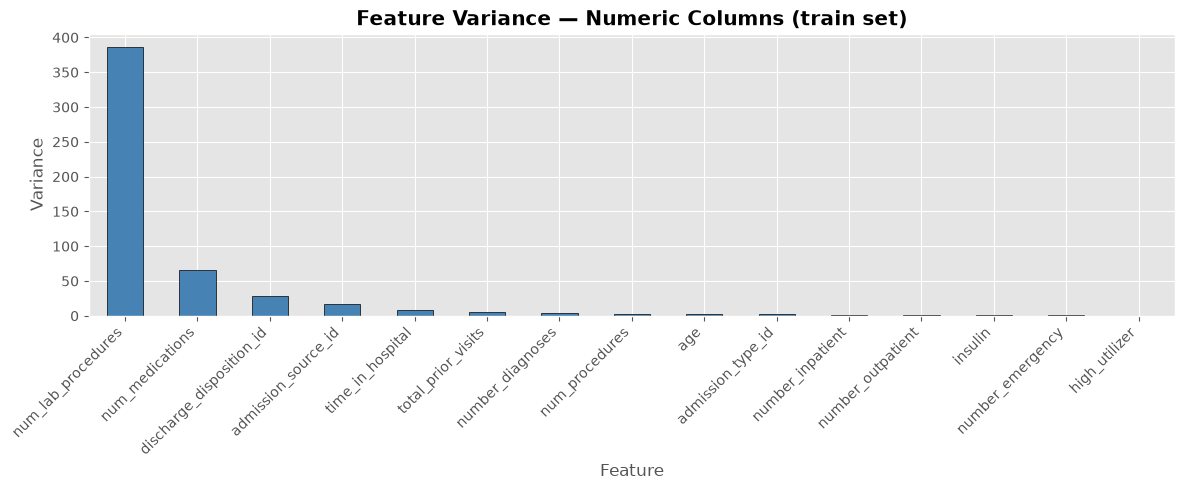


Lowest variance numeric features:
number_inpatient     1.6144
number_outpatient    1.5740
insulin              1.0123
number_emergency     0.9250
high_utilizer        0.1326
dtype: float64


In [21]:
# Only numeric columns can be checked here — string columns will expand after OHE in the Pipeline
numeric_only = X_train.select_dtypes(include=[np.number])
variances = numeric_only.var().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
variances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Variance — Numeric Columns (train set)', fontweight='bold')
plt.ylabel('Variance')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nLowest variance numeric features:")
print(variances.tail(5).round(4))

#### Observation

- `total_prior_visits` and utilization columns will have the highest variance — consistent  
  with being the strongest predictors found in EDA
- `high_utilizer` has low variance by design (binary flag, 15% positive) — that is expected  
- The actual feature importance ranking comes from the Random Forest in `06_random_forest.ipynb`

## Summary

### What We Did in This Notebook

| Step | Transformation | Output |
| ---- | -------------- | ------ |
| 1 | Dropped 10 NZV medication columns | 44 → 34 columns |
| 2 | Created `total_prior_visits` | +1 column |
| 3 | Created `high_utilizer` flag | +1 column |
| 4 | Encoded `age` as ordinal 0–9 | in-place |
| 5 | Encoded `insulin` as ordinal 0–3 | in-place |
| 6 | Collapsed remaining 12 meds to Yes/No | in-place |
| 7 | Imputed `payer_code` and `race` | 0 missing remaining |
| 8 | Verified and saved | `data/features/train_features.csv` |

### What the Pipeline Will Handle in `05_baseline_models.ipynb`

- One-hot encode: `race`, `payer_code`, `diag_group` × 3, `medical_specialty_group`, 3 ID columns  
- Binary encode: `change`, `diabetesMed`, `gender`, 12 medication Yes/No columns

### Key Decisions
- Encoding pushed to Pipeline keeps this notebook focused on **domain-knowledge transforms**
- `age` and `insulin` encoded as **ordinal** — preserves meaningful order that OHE would destroy
- `total_prior_visits` and `high_utilizer` both confirmed with signal checks against y_train
- All data-driven parameters (mode, quantile threshold) fit on **train only**

---

**Next:** [05_baseline_models.ipynb](05_baseline_models.ipynb)